# 02 · What are wind and solar power really worth?

**Research question 2:** How much is Lithuanian wind and solar electricity really worth on the day-ahead
market, and how much wind output is lost when prices turn negative?

Hourly data for January 2023 – August 2026 (the `lt_hourly` view and the `capture_rates_monthly` SQL view,
built by `src/build_db.py`). 2026 covers January–August only, so year-on-year comparisons also use
January–August of every year.

| Hypothesis | Statement |
|---|---|
| H6 | In hours when the Lithuanian price is negative, wind farms produce less electricity than the wind would allow, because some farms are deliberately stopped to avoid losses (economic curtailment). |
| H7 | The capture rate of wind and solar (their output-weighted average price divided by the plain average market price) is below 1 and fell over 2023–2026. Solar's is lower and falls faster than wind's, because all solar parks produce in the same hours and lower the price exactly when they produce. |

**Method in brief.** H6 compares actual Lithuanian wind output with the output the ERA5 wind index predicts,
using a relationship estimated month by month on hours with non-negative prices. H7 is descriptive: capture
rates by year and month, a trend test on monthly capture rates, and the hourly price profile in summer.

In [19]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

con = duckdb.connect(str(ROOT / "data" / "lt_power.duckdb"), read_only=True)
df = con.sql("SELECT * FROM lt_hourly ORDER BY ts_utc").df()
monthly_sql = con.sql("SELECT * FROM capture_rates_monthly ORDER BY month").df()
con.close()

df["year"] = df["ts_local"].dt.year
df["month"] = df["ts_local"].dt.month
df["negative"] = df["price"] < 0
JAN_AUG = df["month"] <= 8
print(f"{len(df):,} hours from {df['ts_local'].min()} to {df['ts_local'].max()}")

32,135 hours from 2023-01-01 00:00:00 to 2026-08-31 23:00:00


In [20]:
def effect(model, name, scale=1.0):
    # Coefficient of one variable with its 95% confidence interval and p-value, times `scale`.
    ci = model.conf_int().loc[name] * scale
    return pd.Series({
        "effect": model.params[name] * scale,
        "ci_low": ci.min(),
        "ci_high": ci.max(),
        "p_value": model.pvalues[name],
    })


def fmt_p(p):
    # p-value as text: a p-value is never exactly 0, so very small values are shown as an upper bound
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def show(table, decimals=3):
    # Round a results table for display; p-values below 0.001 are written as <0.001, since they are never exactly 0
    out = table.round(decimals)
    if "p_value" in out.columns:
        out["p_value"] = table["p_value"].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
    return out

## 1. Negative prices: how often, and when?

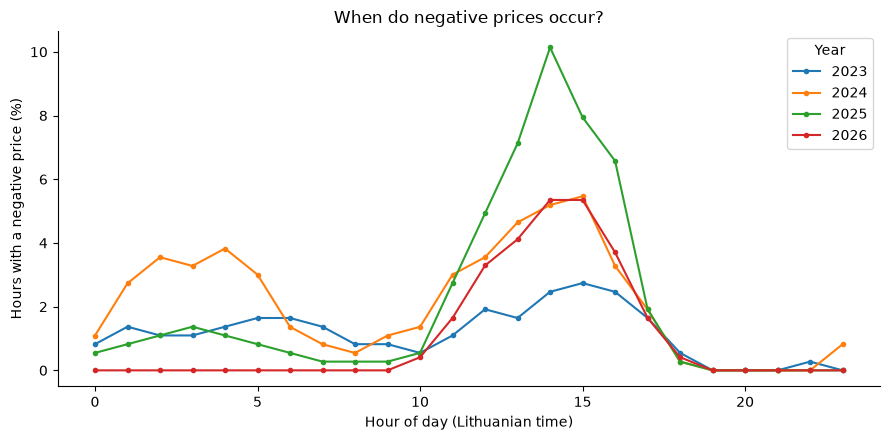

,negative hours,"share of hours, %","negative hours, Jan–Aug"
year,,,
2023,100,1.1,53
2024,186,2.1,125
2025,180,2.1,165
2026,63,1.1,63


In [21]:
negative = pd.DataFrame({
    "negative hours": df.groupby("year")["negative"].sum(),
    "share of hours, %": df.groupby("year")["negative"].mean() * 100,
    "negative hours, Jan–Aug": df[JAN_AUG].groupby("year")["negative"].sum(),
})

share_by_hour = df.groupby(["hour_local", "year"])["negative"].mean().unstack() * 100
fig, ax = plt.subplots()
for year in share_by_hour.columns:
    ax.plot(share_by_hour.index, share_by_hour[year], marker="o", ms=3, label=str(year))
ax.set_xlabel("Hour of day (Lithuanian time)")
ax.set_ylabel("Hours with a negative price (%)")
ax.set_title("When do negative prices occur?")
ax.legend(title="Year")
fig.tight_layout()
fig.savefig(FIG / "q2_negative_hours.png", dpi=150)
plt.show()
negative.round(1)

## 2. H6 — Is wind output curtailed when prices are negative?

**Idea.** The ERA5 wind index says how much the wind *could* produce; ENTSO-E says how much was produced.
For every month, a straight line from the index to actual output is fitted on hours with a non-negative price.
Estimating it month by month absorbs the growth of the fleet. The line then gives the *expected* output in every
hour. If farms are stopped when prices are negative, actual output falls below the expected output in exactly
those hours.

The slope plus intercept of each monthly line is the output at an index of 1 — a rough, data-driven measure of the
fleet's size ("implied capacity"). It is noisy from month to month, because the line is extrapolated to an index
the wind rarely reaches, but its trend can be compared with the known growth of the fleet.

Monthly fits on non-negative hours: median R² = 0.75, lowest 0.59


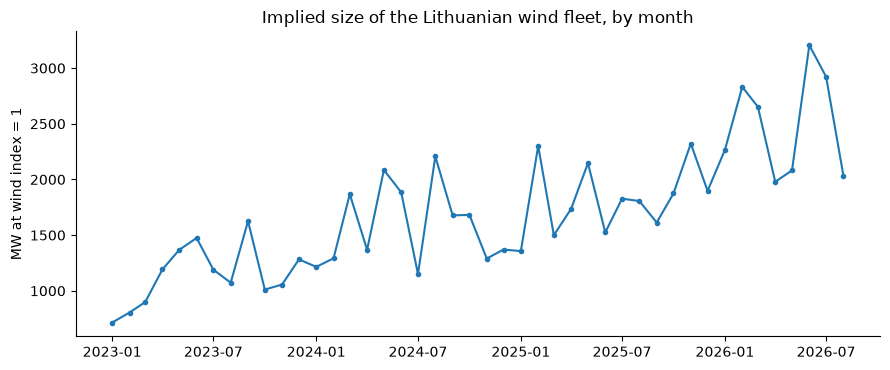

In [22]:
w = df.dropna(subset=["wind_mw", "wind_cf_lt", "price"]).copy()
w["month_id"] = w["ts_local"].dt.to_period("M").astype(str)

parts, fits = [], []
for month_id, g in w.groupby("month_id"):
    base = g[~g["negative"]]
    slope, intercept = np.polyfit(base["wind_cf_lt"], base["wind_mw"], 1)
    parts.append(g.assign(expected_mw=np.clip(intercept + slope * g["wind_cf_lt"], 0, None)))
    fits.append({"month": pd.Period(month_id), "implied capacity, MW": intercept + slope,
                 "R²": base["wind_cf_lt"].corr(base["wind_mw"]) ** 2,
                 "negative hours": int(g["negative"].sum())})
w = pd.concat(parts).sort_values("ts_utc")
fits = pd.DataFrame(fits).set_index("month")
print(f"Monthly fits on non-negative hours: median R² = {fits['R²'].median():.2f}, lowest {fits['R²'].min():.2f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(fits.index.to_timestamp(), fits["implied capacity, MW"], marker="o", ms=3)
ax.set_ylabel("MW at wind index = 1")
ax.set_title("Implied size of the Lithuanian wind fleet, by month")
fig.tight_layout()
fig.savefig(FIG / "q2_implied_capacity.png", dpi=150)
plt.show()

### 2.1 Actual against expected output
Hours are grouped by expected output. If the monthly lines fitted perfectly, the line for non-negative prices
would lie on the diagonal. Where it bends away from it, the link between the ERA5 index and output is not quite
linear. That is why the test below compares hours **with the same expected output** rather than relying on the
diagonal.

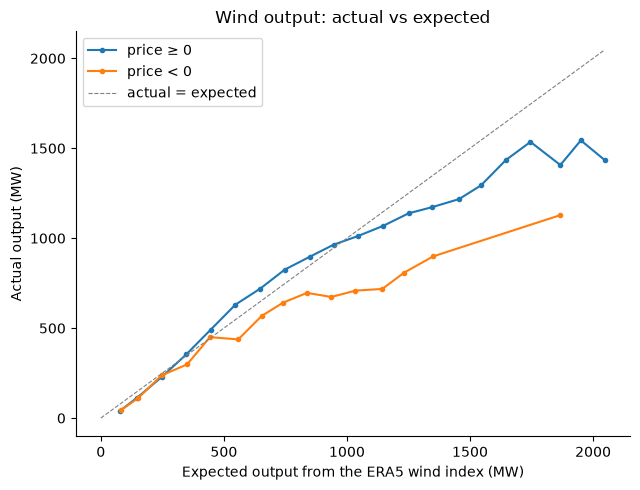

In [23]:
w["shortfall_mw"] = w["expected_mw"] - w["wind_mw"]
w["expected_bin"] = pd.cut(w["expected_mw"], np.arange(0, w["expected_mw"].max() + 100, 100))
binned = (w.groupby(["negative", "expected_bin"], observed=True)
            .agg(expected=("expected_mw", "mean"), actual=("wind_mw", "mean"), hours=("wind_mw", "size"))
            .reset_index())
binned = binned[binned["hours"] >= 10]

fig, ax = plt.subplots(figsize=(6.5, 5))
for is_negative, label in [(False, "price ≥ 0"), (True, "price < 0")]:
    g = binned[binned["negative"] == is_negative]
    ax.plot(g["expected"], g["actual"], marker="o", ms=3, label=label)
top = binned["expected"].max()
ax.plot([0, top], [0, top], color="grey", lw=0.8, ls="--", label="actual = expected")
ax.set_xlabel("Expected output from the ERA5 wind index (MW)")
ax.set_ylabel("Actual output (MW)")
ax.set_title("Wind output: actual vs expected")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q2_curtailment.png", dpi=150)
plt.show()

### 2.2 Test and a placebo by price band
For each band of expected output, the reference is the average actual output in hours with a clearly profitable
price (≥ 10 €/MWh). Every hour's gap is its output below that reference, in % — so hours are only compared with
hours of the same expected output, which removes the curvature seen above. The gap is then compared between
price bands, with standard errors clustered by month (negative-price hours come in episodes). Hours with less than
100 MW of expected output are left out, because a percentage is meaningless in calm hours.

The **0–10 €/MWh band is the placebo**: those hours have similar weather and time of day (windy, often midday),
but producing is still profitable, so no gap should appear there. The simple comparison against all non-negative
hours, without matching, is shown for reference.

In [24]:
reference = w[w["price"] >= 10].groupby("expected_bin", observed=True)["wind_mw"].mean()
w["reference_mw"] = w["expected_bin"].map(reference).astype(float)

valid = w[(w["expected_mw"] >= 100) & w["reference_mw"].notna()].copy()
valid["gap_pct"] = 100 * (1 - valid["wind_mw"] / valid["reference_mw"])
valid["band"] = pd.cut(valid["price"], [-np.inf, 0, 10, np.inf], right=False, labels=["negative", "0-10", "10+"])
valid["month_code"] = pd.factorize(valid["month_id"])[0]
cluster = {"cov_type": "cluster", "cov_kwds": {"groups": valid["month_code"].to_numpy()}}

m_h6 = smf.ols("gap_pct ~ C(band, Treatment('10+'))", data=valid).fit(**cluster)
h6 = effect(m_h6, "C(band, Treatment('10+'))[T.negative]")
h6_placebo = effect(m_h6, "C(band, Treatment('10+'))[T.0-10]")

valid["shortfall_pct"] = 100 * (valid["expected_mw"] - valid["wind_mw"]) / valid["expected_mw"]
valid["negative_int"] = valid["negative"].astype(int)
h6_simple = effect(smf.ols("shortfall_pct ~ negative_int", data=valid).fit(**cluster), "negative_int")

print(f"Hours compared: {int((valid['band'] == 'negative').sum())} negative, "
      f"{int((valid['band'] == '0-10').sum())} at 0–10 €/MWh, {int((valid['band'] == '10+').sum()):,} at ≥ 10 €/MWh")
pd.DataFrame({
    "negative price vs ≥ 10 €/MWh, same expected output": h6,
    "placebo: 0–10 €/MWh vs ≥ 10 €/MWh, same expected output": h6_placebo,
    "simple comparison, not matched (for reference)": h6_simple,
}).T.pipe(show, 2)

Hours compared: 504 negative, 2758 at 0–10 €/MWh, 26,289 at ≥ 10 €/MWh


,effect,ci_low,ci_high,p_value
"negative price vs ≥ 10 €/MWh, same expected output",18.07,9.92,26.23,<0.001
"placebo: 0–10 €/MWh vs ≥ 10 €/MWh, same expected output",0.93,-3.87,5.74,0.703
"simple comparison, not matched (for reference)",14.07,6.18,21.96,<0.001


### 2.3 How much wind energy is lost?
Lost energy is the matched reference output (section 2.2) minus actual output, summed over negative-price hours.
It is an estimate: individual hours can land above or below the reference, and only the sum is meaningful.
2026 covers January–August only.

In [25]:
w["potential_mw"] = np.where(w["negative"], w["reference_mw"].fillna(w["expected_mw"]), w["wind_mw"])
neg_w = w[w["negative"]]
lost = neg_w.groupby("year").agg(negative_hours=("wind_mw", "size"),
                                 potential_mwh=("potential_mw", "sum"),
                                 actual_mwh=("wind_mw", "sum"))
lost["curtailed_mwh"] = lost["potential_mwh"] - lost["actual_mwh"]
lost["curtailed, % of potential in these hours"] = 100 * lost["curtailed_mwh"] / lost["potential_mwh"]
lost["curtailed, % of the year's wind output"] = 100 * lost["curtailed_mwh"] / w.groupby("year")["wind_mw"].sum()
lost.round(1)

,negative_hours,potential_mwh,actual_mwh,curtailed_mwh,"curtailed, % of potential in these hours","curtailed, % of the year's wind output"
year,,,,,,
2023,100,54734.6,49515.5,5219.1,9.5,0.2
2024,186,114500.5,84071.9,30428.5,26.6,0.9
2025,180,109644.6,77838.1,31806.5,29.0,0.8
2026,63,57244.5,43642.2,13602.3,23.8,0.4


## 3. H7 — Capture rates

**Capture price** = output-weighted average price: what a technology actually earns per MWh.
**Capture rate** = capture price ÷ plain (baseload) average price. A rate below 1 means the technology produces
mostly when prices are low. The **discount** is baseload minus capture price in €/MWh.

### 3.1 By year

In [26]:
rows = []
for period, data in [("full year", df), ("January–August", df[JAN_AUG])]:
    for year, g in data.groupby("year"):
        if period == "full year" and year == df["year"].max():
            continue                                     # the last year is incomplete
        base = g["price"].mean()
        row = {"period": period, "year": year, "baseload €/MWh": base}
        for tech, col in [("wind", "wind_mw"), ("solar", "solar_mw")]:
            ok = g.dropna(subset=[col])
            captured = (ok[col] * ok["price"]).sum() / ok[col].sum()
            row[f"{tech} capture €/MWh"] = captured
            row[f"{tech} capture rate"] = captured / base
            row[f"{tech} discount €/MWh"] = base - captured
        rows.append(row)
yearly = pd.DataFrame(rows).set_index(["period", "year"])
yearly.round(3)

baseload €/MWh  wind capture €/MWh  wind capture rate  \
period         year                                                          
full year      2023          94.438              78.494              0.831   
               2024          87.341              70.837              0.811   
               2025          85.301              69.070              0.810   
January–August 2023          91.876              81.295              0.885   
               2024          86.815              73.792              0.850   
               2025          79.951              65.117              0.814   
               2026          96.958              87.391              0.901   

                     wind discount €/MWh  solar capture €/MWh  \
period         year                                             
full year      2023               15.943               85.282   
               2024               16.504               66.979   
               2025               16.232               50.085   
January–August 2023               10.581               79.696   
               2024               13.023               65.092   
               2025               14.834               44.485   
               2026                9.568               52.497   

                     solar capture rate  solar discount €/MWh  
period         year                                            
full year      2023               0.903                 9.155  
               2024               0.767                20.362  
               2025               0.587                35.216  
January–August 2023               0.867                12.181  
               2024               0.750                21.723  
               2025               0.556                35.466  
               2026               0.541                44.462

### 3.2 By month
The monthly capture rates come straight from the SQL view `capture_rates_monthly`; a quick check confirms
that pandas gives the same numbers.

SQL view vs pandas, largest difference in the monthly wind capture rate: 2.7e-15


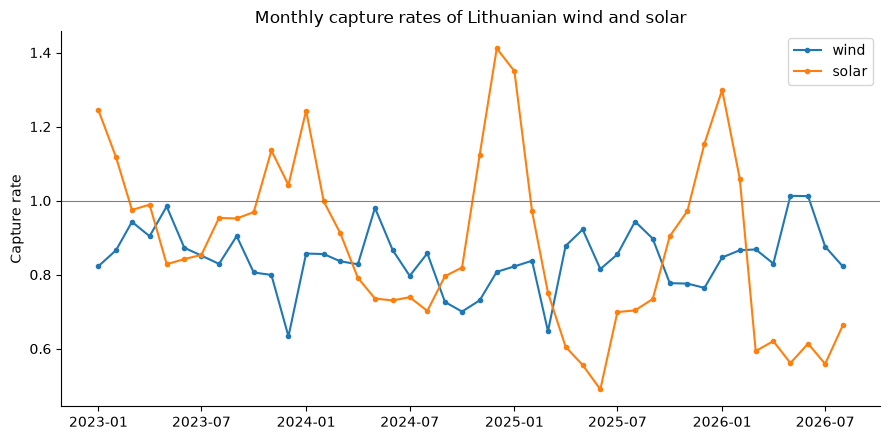

In [27]:
monthly = monthly_sql.assign(month=pd.to_datetime(monthly_sql["month"])).set_index("month")

tmp = df.assign(month_start=df["ts_local"].dt.to_period("M").dt.to_timestamp(),
                wind_value=df["wind_mw"] * df["price"])
agg = tmp.groupby("month_start").agg(wind_value=("wind_value", "sum"), wind_mwh=("wind_mw", "sum"),
                                     solar_mwh=("solar_mw", "sum"), baseload=("price", "mean"))
pandas_rate = agg["wind_value"] / agg["wind_mwh"] / agg["baseload"]
gap = (pandas_rate - monthly["wind_capture_rate"].reindex(agg.index)).abs().max()
print(f"SQL view vs pandas, largest difference in the monthly wind capture rate: {gap:.1e}")

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["wind_capture_rate"], marker="o", ms=3, label="wind")
ax.plot(monthly.index, monthly["solar_capture_rate"], marker="o", ms=3, label="solar")
ax.axhline(1, color="grey", lw=0.8)
ax.set_ylabel("Capture rate")
ax.set_title("Monthly capture rates of Lithuanian wind and solar")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q2_capture_rates_monthly.png", dpi=150)
plt.show()

### 3.3 Are capture rates falling?
Monthly capture rates are regressed on a time trend with month-of-year effects, so the seasonal cycle does not
count as a trend. Each month is weighted by the technology's output, so months with little output (solar in
winter) count less. The trend is in percentage points of capture rate per year.

In [28]:
trend_rows = {}
for tech in ["wind", "solar"]:
    t = pd.DataFrame({"rate": monthly[f"{tech}_capture_rate"], "mwh": agg[f"{tech}_mwh"]}).dropna()
    t = t[t["mwh"] > 0]
    t["trend"] = (t.index - pd.Timestamp("2023-01-01")).days / 365.25
    t["moy"] = t.index.month
    m_trend = smf.wls("rate ~ trend + C(moy)", data=t, weights=t["mwh"]).fit(
        cov_type="HAC", cov_kwds={"maxlags": 3})
    trend_rows[tech] = effect(m_trend, "trend", 100)
trends = pd.DataFrame(trend_rows).T
show(trends, 2)

,effect,ci_low,ci_high,p_value
wind,0.25,-1.27,1.77,0.744
solar,-8.41,-10.53,-6.28,<0.001


### 3.4 The midday dip
Average price by hour of day in April–August, with the average solar output profile in the background.
If solar cannibalises its own value, the midday dip should deepen as solar capacity grows.

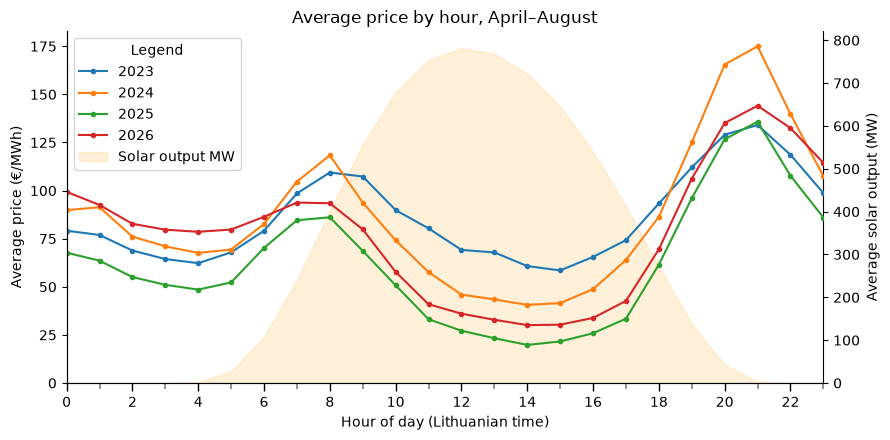

In [51]:
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

summer = df[df["month"].between(4, 8)]
profile = summer.groupby(["hour_local", "year"])["price"].mean().unstack()
solar_shape = summer.groupby("hour_local")["solar_mw"].mean()

solar_patch = mpatches.Patch(color="orange", alpha=0.15, label="Solar output MW")

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax2.fill_between(solar_shape.index, solar_shape.values, color="orange", alpha=0.15)
ax2.set_ylabel("Average solar output (MW)")
ax2.spines["right"].set_visible(True)
ax2.spines["top"].set_visible(False)
for year in profile.columns:
    ax.plot(profile.index, profile[year], marker="o", ms=3, label=str(year))
    
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax.tick_params(
    axis="x",
    which="minor",
    length=4,
    width=1.2,
    color="grey",
    direction="out",  # Tick direction: 'in', 'out', or 'inout'
)
ax.tick_params(
    axis="x",
    which="major",
    length=6,
    width=1
    )

ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.set_xmargin(0)
ax.set_xlabel("Hour of day (Lithuanian time)")
ax.set_ylabel("Average price (€/MWh)")
ax.set_title("Average price by hour, April–August")

handles, labels = ax.get_legend_handles_labels()
handles.append(solar_patch)
ax.legend(handles=handles, title="Legend")

fig.tight_layout()
fig.savefig(FIG / "q2_midday_dip.png", dpi=150)
plt.show()

### 3.5 Curtailment and the wind capture rate
Stopping at negative prices avoids selling at a loss, so it should raise the capture rate. Here the capture rate
of actual output is compared with that of the output the wind would have allowed (expected output in
negative-price hours, from the matched reference in section 2.2).

In [30]:
pot = w.copy()
pot["value_actual"] = pot["wind_mw"] * pot["price"]
pot["value_potential"] = pot["potential_mw"] * pot["price"]
a = pot.groupby("year").agg(value_actual=("value_actual", "sum"), mwh_actual=("wind_mw", "sum"),
                            value_potential=("value_potential", "sum"), mwh_potential=("potential_mw", "sum"),
                            baseload=("price", "mean"))
curtail_value = pd.DataFrame({
    "capture rate, actual output": a["value_actual"] / a["mwh_actual"] / a["baseload"],
    "capture rate without curtailment": a["value_potential"] / a["mwh_potential"] / a["baseload"],
})
curtail_value["gain from curtailment, pp"] = 100 * (curtail_value.iloc[:, 0] - curtail_value.iloc[:, 1])
curtail_value.round(3)

,"capture rate, actual output",capture rate without curtailment,"gain from curtailment, pp"
year,,,
2023,0.831,0.830,0.178
2024,0.811,0.803,0.772
2025,0.810,0.803,0.698
2026,0.901,0.898,0.376


## 4. Summary of H6–H7

H6 is supported when, compared with profitable hours of the same expected output, output in negative-price hours is
significantly lower (p < 0.05) and the 0–10 €/MWh placebo band shows no comparable gap.

H7 has several parts: both capture rates below 1 in every year; each capture rate falling (negative, significant
trend); solar below wind now; solar falling faster. It is supported when all parts hold and partly supported when
the rates are below 1 and at least one technology's rate is falling.

In [31]:
def verdict(ok):
    return "supported" if ok else "not supported"

placebo_small = h6_placebo["p_value"] >= 0.05 or abs(h6_placebo["effect"]) < h6["effect"] / 2
h6_ok = h6["effect"] > 0 and h6["p_value"] < 0.05 and placebo_small

last_full = yearly.loc["full year"].index.max()
last_ja = yearly.loc["January–August"].index.max()
parts = {
    "both rates below 1 every year": bool((yearly[["wind capture rate", "solar capture rate"]] < 1).all().all()),
    "wind rate falling": bool(trends.loc["wind", "effect"] < 0 and trends.loc["wind", "p_value"] < 0.05),
    "solar rate falling": bool(trends.loc["solar", "effect"] < 0 and trends.loc["solar", "p_value"] < 0.05),
    "solar below wind now": bool(
        yearly.loc[("full year", last_full), "solar capture rate"] < yearly.loc[("full year", last_full), "wind capture rate"]
        and yearly.loc[("January–August", last_ja), "solar capture rate"] < yearly.loc[("January–August", last_ja), "wind capture rate"]),
    "solar falling faster": bool(trends.loc["solar", "effect"] < trends.loc["wind", "effect"]),
}
h7_verdict = ("supported" if all(parts.values())
              else "partly supported" if parts["both rates below 1 every year"]
              and (parts["wind rate falling"] or parts["solar rate falling"])
              else "not supported")
print("H7 parts:", parts)

summary = pd.DataFrame([
    ["H6", "Wind output falls below what the wind allows when prices are negative",
     f"{h6['effect']:.1f}% lower output than profitable hours with the same expected output "
     f"({fmt_p(h6['p_value'])}); placebo 0–10 €/MWh: {h6_placebo['effect']:.1f}% ({fmt_p(h6_placebo['p_value'])})",
     verdict(h6_ok)],
    ["H7", "Capture rates below 1 and falling; solar lower and falling faster",
     f"{last_full}: wind {yearly.loc[('full year', last_full), 'wind capture rate']:.2f}, "
     f"solar {yearly.loc[('full year', last_full), 'solar capture rate']:.2f}; trend per year: "
     f"wind {trends.loc['wind', 'effect']:+.1f} pp ({fmt_p(trends.loc['wind', 'p_value'])}), "
     f"solar {trends.loc['solar', 'effect']:+.1f} pp ({fmt_p(trends.loc['solar', 'p_value'])})",
     h7_verdict],
], columns=["hypothesis", "statement", "estimate", "verdict"])
summary.to_csv(FIG / "q2_summary.csv", index=False)
summary

H7 parts: {'both rates below 1 every year': True, 'wind rate falling': False, 'solar rate falling': True, 'solar below wind now': True, 'solar falling faster': True}


,hypothesis,statement,estimate,verdict
0,H6,Wind output falls below what the wind allows w...,18.1% lower output than profitable hours with ...,supported
1,H7,Capture rates below 1 and falling; solar lower...,"2025: wind 0.81, solar 0.59; trend per year: w...",partly supported
